[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kulinskij-tech/AtomicPhys/blob/main/Atomic_py/sphcoordlaplace_we.ipynb)


# Оператор Лапласа та момент імпульсу у сферичних координатах

Використовуючі відповідні формули прямого та зворотнього переходу:

{x -> r Cos[φ] Sin[θ], y -> r Sin[θ] Sin[φ], z -> r Cos[θ]}
      2    2    2
Sqrt[x  + y  + z ]
             2    2
       Sqrt[x  + y ]
ArcTan[-------------]
             z
       y
ArcTan[-]
       x
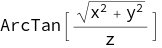
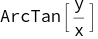

In [1]:
rl = {x -> r*Sin[\[Theta]]*Cos[\[CurlyPhi]], 
  y -> r*Sin[\[Theta]]*Sin[\[CurlyPhi]], z -> r*Cos[\[Theta]]}
x =.; y =.; z =.;
r1 = Sqrt[x^2 + y^2 + z^2]
\[Theta]1 = ArcTan[Sqrt[x^2 + y^2]/z]
\[CurlyPhi]1 = ArcTan[y/x]

 будуємо відповідні компоненти оператора імпульсу $p = -i\,\nabla$

In [6]:
pdx[f_] := -I (D[f, r]*D[r1, x] + D[f, \[Theta]]*D[\[Theta]1, x] + 
    D[f, \[CurlyPhi]]*D[\[CurlyPhi]1, x])
pdy[f_] := -I (D[f, r]*D[r1, y] + D[f, \[Theta]]*D[\[Theta]1, y] + 
    D[f, \[CurlyPhi]]*D[\[CurlyPhi]1, y])
pdz[f_] := -I (D[f, r]*D[r1, z] + D[f, \[Theta]]*D[\[Theta]1, z])
lx[f_] := y*pdz[f] - z*pdy[f]
ly[f_] := z*pdx[f] - x*pdz[f]
lz[f_] := x*pdy[f] - y*pdx[f]

Оператор $\Delta$ у сферичних координатах:

2  (0,0,2)                     (0,1,0)             (0,2,0)
-(Csc[θ]  f       [r, θ, φ]) - Cot[θ] f       [r, θ, φ] - f       [r, θ, φ]
--------------------------------------------------------------------------- - 
                                     2
                                    r
 
       (1,0,0)
    2 f       [r, θ, φ]    (2,0,0)
>   ------------------- - f       [r, θ, φ]
             r
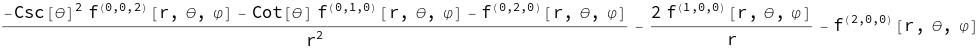

In [12]:
lapp = Collect[
  Expand@Simplify[
    Expand[Assuming[{r > 0, Sin[\[Theta]] > 0, \[CurlyPhi] > 0}, 
       Simplify[
        pdx[Assuming[{r > 0, Sin[\[Theta]] > 0, \[CurlyPhi] > 0}, 
           Simplify[pdx[f[r, \[Theta], \[CurlyPhi]]] /. rl]]] /. rl]] +
      Assuming[{r > 0, Sin[\[Theta]] > 0, \[CurlyPhi] > 0}, 
       Simplify[
        pdy[Assuming[{r > 0, Sin[\[Theta]] > 0, \[CurlyPhi] > 0}, 
           Simplify[pdy[f[r, \[Theta], \[CurlyPhi]]] /. rl]]] /. rl]] +
      Assuming[{r > 0, Sin[\[Theta]] > 0, \[CurlyPhi] > 0}, 
       Simplify[
        pdz[Assuming[{r > 0, Sin[\[Theta]] > 0, \[CurlyPhi] > 0}, 
           Simplify[pdz[f[r, \[Theta], \[CurlyPhi]]] /. rl]]] /. 
         rl]]]], 1/r]

Оператор $\mathbf{L}^2$ у сферичних координатах:

In [13]:
lapl = Expand@
  Simplify[Expand[
    Assuming[{r > 0, Sin[\[Theta]] > 0, \[CurlyPhi] > 0}, 
      Simplify[
       lx[Assuming[{r > 0, Sin[\[Theta]] > 0, \[CurlyPhi] > 0}, 
          Simplify[lx[f[r, \[Theta], \[CurlyPhi]]] /. rl]]] /. rl]] +
     Assuming[{r > 0, Sin[\[Theta]] > 0, \[CurlyPhi] > 0}, 
      Simplify[
       ly[Assuming[{r > 0, Sin[\[Theta]] > 0, \[CurlyPhi] > 0}, 
          Simplify[ly[f[r, \[Theta], \[CurlyPhi]]] /. rl]]] /. rl]] +
     Assuming[{r > 0, Sin[\[Theta]] > 0, \[CurlyPhi] > 0}, 
      Simplify[
       lz[Assuming[{r > 0, Sin[\[Theta]] > 0, \[CurlyPhi] > 0}, 
          Simplify[lz[f[r, \[Theta], \[CurlyPhi]]] /. rl]]] /. rl]]]]

2  (0,0,2)                     (0,1,0)             (0,2,0)
-(Csc[θ]  f       [r, θ, φ]) - Cot[θ] f       [r, θ, φ] - f       [r, θ, φ]

Перевірка співпадіння кутової частини $\Delta$ з $\mathbf{L}^2$ :

In [14]:
lapl == Coefficient[lapp, 1/r^2]

True